# Automation with AI Agents for Peloton Services
## Phase 3 - Complete Implementation

**Author:** Deorukhkar  
**Course:** Final Project - Phase 3
**Framework:** LangChain 1.0 + LangGraph + OpenAI GPT-4o

---

This notebook extends Phase 2 to provide **complete implementation** of all **3 user stories for every AI Agent** (15 user stories total).

| Agent | US1 | US2 | US3 |
|-------|-----|-----|-----|
| Business / Marketing | Black Friday Campaign ROI | Q2 Content Strategy | Competitor Analysis |
| Data Science | Cycling Performance | Workout Consistency | Demographic Class Report |
| Membership / Fraud | Suspicious Device Activity | Password Reset | Membership Tier Comparison |
| Order / Shipping | Order Tracking | Return Process | Delayed Order Escalation |
| Product Recommendation | Yoga Accessories | Bike vs Bike+ Comparison | Cross-Sell Tread Bundles |

## 1. Setup & Dependencies

In [1]:
# !pip install -q langchain langchain-openai langgraph openai python-dotenv

In [2]:
import os
import json
from typing import TypedDict, Literal, Optional

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import tool
from langchain.agents import create_agent
from langgraph.graph import StateGraph, END

# os.environ["OPENAI_API_KEY"] = "sk-..."

LLM_MODEL = "gpt-4o"
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)
print(f"Loaded LLM: {LLM_MODEL}")

Loaded LLM: gpt-4o


## 2. Training Data Inventory

| # | Agent | Training File | Testing File |
|---|-------|---------------|--------------|
| 1 | Business / Marketing | `business_marketing_training.json` | `business_marketing_testing.json` |
| 2 | Data Science | `data_science_training.json` | `data_science_testing.json` |
| 3 | Membership / Fraud | `membership_fraud_training.json` | `membership_fraud_testing.json` |
| 4 | Order / Shipping | `order_shipping_training.json` | `order_shipping_testing.json` |
| 5 | Product Recommendation | `product_recommendation_training.json` | `product_recommendation_testing.json` |

In [3]:
TRAINING_DIR = os.path.join("..", "training_data")

def load_training_pairs(agent_slug: str, max_examples: int = 4) -> list:
    path = os.path.join(TRAINING_DIR, f"{agent_slug}_training.json")
    if not os.path.exists(path):
        return []
    with open(path) as f:
        data = json.load(f)
    pairs = []
    for item in data.get("training_data", [])[:max_examples]:
        msgs = item["messages"]
        user = next((m["content"] for m in msgs if m["role"] == "user"), "")
        assistant = next((m["content"] for m in msgs if m["role"] == "assistant"), "")
        pairs.append((user, assistant))
    return pairs

sample = load_training_pairs("business_marketing", max_examples=1)
print(f"Loaded {len(sample)} sample pair(s)")

Loaded 1 sample pair(s)


## 3. Shared Graph State

In [4]:
class AgentState(TypedDict):
    user_input: str
    routed_to: str
    agent_response: str
    human_review: bool
    trace: list

## 4. Router AI Agent

In [5]:
ROUTER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", """You are the Router Agent for Peloton's AI assistant platform.
Classify the user's query into EXACTLY ONE slug:

- business_marketing    : marketing campaigns, ROI, content strategy, competitor analysis
- data_science          : fitness metrics, performance trends, workout analytics, demographic reports
- membership_fraud      : account security, suspicious activity, password reset, tier upgrades
- order_shipping        : order status, shipping, returns, exchanges, warranty, delayed orders
- product_recommendation: product suggestions, comparisons, bundles, accessories, pricing

Respond with ONLY the slug. No punctuation, no explanation."""),
    ("human", "{user_input}"),
])

VALID_AGENTS = {
    "business_marketing", "data_science", "membership_fraud",
    "order_shipping", "product_recommendation",
}
HUMAN_REVIEW_TRIGGERS = ("refund", "suspend", "dispute", "fraud", "chargeback", "escalat")

def router_node(state: AgentState) -> AgentState:
    chain = ROUTER_PROMPT | llm
    result = chain.invoke({"user_input": state["user_input"]})
    routed_to = result.content.strip().lower()
    if routed_to not in VALID_AGENTS:
        routed_to = "product_recommendation"
    needs_review = any(t in state["user_input"].lower() for t in HUMAN_REVIEW_TRIGGERS)
    trace = state.get("trace", []) + [f"Router -> {routed_to} (review={needs_review})"]
    return {**state, "routed_to": routed_to, "human_review": needs_review, "trace": trace}

def route_condition(state: AgentState) -> Literal[
    "business_marketing", "data_science", "membership_fraud",
    "order_shipping", "product_recommendation"
]:
    return state["routed_to"]

## 5. Specialist Agents

Each agent now has **enough tools to handle all 3 user stories** from Phase 1.

In [6]:
def build_specialist_agent(base_prompt: str, tools: list, few_shot_slug: Optional[str] = None):
    system_prompt = base_prompt
    if few_shot_slug:
        pairs = load_training_pairs(few_shot_slug, max_examples=4)
        if pairs:
            shots = "\n\n".join(f"Example:\nUser: {u}\nAssistant: {a}" for u, a in pairs)
            system_prompt = f"{base_prompt}\n\n--- Few-shot examples ---\n{shots}"
    return create_agent(model=llm, tools=tools, system_prompt=system_prompt)

def run_specialist(agent, user_input: str) -> str:
    result = agent.invoke({"messages": [{"role": "user", "content": user_input}]})
    final = result["messages"][-1].content
    if isinstance(final, list):
        final = "".join(part.get("text", "") if isinstance(part, dict) else str(part) for part in final)
    return final

### 5.1 Business / Marketing AI Agent

| Story | Description |
|-------|-------------|
| US1 | Analyze Black Friday Campaign ROI — identify top ads and recommend budget reallocation |
| US2 | Q2 Content Strategy — identify high-engagement themes and suggest social calendar topics |
| US3 | Competitor Analysis — compare Peloton membership growth to NordicTrack and Echelon |

In [7]:
@tool
def get_campaign_analytics(campaign_name: str) -> str:
    """Fetch KPIs for a named marketing campaign: impressions, clicks, conversions, spend, ROI, top/bottom ads."""
    mock = {
        "Black Friday Tread Campaign": {
            "impressions": 4_200_000, "clicks": 189_000, "ctr_percent": 4.5,
            "conversions": 3_402, "spend_usd": 210_000, "revenue_usd": 5_103_000,
            "roi_percent": 2330,
            "top_ads": [
                {"name": "Fall Into Fitness (video)", "ctr": 4.8},
                {"name": "Ride With Us (carousel)", "ctr": 3.9},
                {"name": "Your Goals, Our Classes (static)", "ctr": 3.2},
            ],
            "bottom_ads": [{"name": "Static Banner v2", "ctr": 1.1}],
        }
    }
    return json.dumps(mock.get(campaign_name, {"error": f"Campaign '{campaign_name}' not found"}), indent=2)

@tool
def get_engagement_data(months: int = 6) -> str:
    """Return aggregated member content engagement metrics for the last N months."""
    return json.dumps({
        "period_months": months,
        "top_themes": [
            {"theme": "HIIT Cycling", "engagement_rate": 0.18, "shares": 42000},
            {"theme": "Beginner Yoga", "engagement_rate": 0.15, "shares": 31000},
            {"theme": "Mental Wellness", "engagement_rate": 0.13, "shares": 27000},
            {"theme": "Strength for Runners", "engagement_rate": 0.11, "shares": 19000},
            {"theme": "Recovery & Stretching", "engagement_rate": 0.10, "shares": 16500},
        ],
    }, indent=2)

@tool
def get_competitor_data(competitor: str) -> str:
    """Fetch competitive intelligence: membership size, growth rate, pricing, and content strategy for a competitor."""
    db = {
        "NordicTrack": {
            "est_members": 1_800_000, "yoy_growth_pct": 8.2, "monthly_price_usd": 39,
            "content_strategy": "iFit integration with Google Maps-based outdoor runs and rides",
            "strengths": ["lower price point", "wider equipment range"],
            "weaknesses": ["smaller class library", "less community engagement"],
        },
        "Echelon": {
            "est_members": 900_000, "yoy_growth_pct": 12.5, "monthly_price_usd": 34.99,
            "content_strategy": "Live leaderboard competitions and budget-tier equipment",
            "strengths": ["aggressive pricing", "fast growth in budget segment"],
            "weaknesses": ["instructor roster depth", "brand perception vs premium"],
        },
        "Peloton": {
            "est_members": 6_400_000, "yoy_growth_pct": 3.1, "monthly_price_usd": 44,
            "content_strategy": "Premium instructor-led classes, social features, artist series",
            "strengths": ["brand loyalty", "instructor quality", "community"],
            "weaknesses": ["higher price point", "slowing growth"],
        },
    }
    return json.dumps(db.get(competitor, {"error": f"No data for '{competitor}'"}), indent=2)

bm_agent = build_specialist_agent(
    base_prompt=(
        "You are Peloton's Business/Marketing AI Agent. You help the marketing team "
        "analyze campaigns, ROI, engagement, competitor data, and content strategy. "
        "Be concise, cite specific numbers from your tools, and always finish with "
        "an actionable recommendation."
    ),
    tools=[get_campaign_analytics, get_engagement_data, get_competitor_data],
    few_shot_slug="business_marketing",
)

def business_marketing_node(state: AgentState) -> AgentState:
    response = run_specialist(bm_agent, state["user_input"])
    trace = state.get("trace", []) + ["BusinessMarketingAgent executed"]
    return {**state, "agent_response": response, "trace": trace}

### 5.2 Data Science AI Agent

| Story | Description |
|-------|-------------|
| US1 | Cycling Performance — review last 30 classes and suggest output/cadence improvements |
| US2 | Workout Consistency — show workout patterns over 3 months and recommend a schedule |
| US3 | Demographic Class Report — popular class types by age group and instructor completion rates |

In [8]:
@tool
def get_cycling_performance(member_id: str, last_n: int = 30) -> str:
    """Retrieve output, cadence, resistance, and heart rate summary for a member's last N cycling classes."""
    return json.dumps({
        "member_id": member_id, "classes_analyzed": last_n,
        "avg_output_kj": 312, "avg_cadence_rpm": 86, "avg_resistance": 42, "avg_heart_rate": 148,
        "trend": {"output": "+4.2% vs prior 30", "cadence": "-1.1% vs prior 30"},
        "peer_benchmark": {"avg_output_kj": 298, "top_quartile_output_kj": 365},
    }, indent=2)

@tool
def get_class_recommendations(focus: str) -> str:
    """Recommend Peloton classes that target a specific training focus such as 'cadence' or 'power'."""
    catalog = {
        "cadence": ["PZ Endurance with Matt Wilpers (45 min)", "Tabata Ride with Robin Arzon (30 min)"],
        "power": ["Power Zone Max with Denis Morton (45 min)", "Climb Ride with Christine D'Ercole (30 min)"],
        "consistency": ["20 min Low Impact with Sam Yo", "15 min Cool Down with Cody Rigsby"],
    }
    return json.dumps({"focus": focus, "classes": catalog.get(focus, [])}, indent=2)

@tool
def get_workout_consistency(member_id: str, months: int = 3) -> str:
    """Return weekly workout frequency, streaks, and rest patterns for a member over N months."""
    return json.dumps({
        "member_id": member_id, "period_months": months,
        "weekly_breakdown": [
            {"week": "W1-Jan", "workouts": 5}, {"week": "W2-Jan", "workouts": 3},
            {"week": "W3-Jan", "workouts": 4}, {"week": "W4-Jan", "workouts": 2},
            {"week": "W1-Feb", "workouts": 5}, {"week": "W2-Feb", "workouts": 1},
            {"week": "W3-Feb", "workouts": 4}, {"week": "W4-Feb", "workouts": 4},
            {"week": "W1-Mar", "workouts": 3}, {"week": "W2-Mar", "workouts": 5},
            {"week": "W3-Mar", "workouts": 2}, {"week": "W4-Mar", "workouts": 4},
        ],
        "avg_per_week": 3.5, "longest_streak_days": 14, "most_common_rest_day": "Sunday",
        "disciplines": {"cycling": 55, "strength": 25, "yoga": 15, "stretching": 5},
    }, indent=2)

@tool
def get_demographic_report(age_group: str = "25-34", region: str = "Northeast") -> str:
    """Return the most popular class types and top instructors for a demographic segment."""
    return json.dumps({
        "age_group": age_group, "region": region,
        "top_class_types": [
            {"type": "HIIT & Hills Ride", "pct_of_segment": 22},
            {"type": "Power Zone", "pct_of_segment": 18},
            {"type": "Bootcamp", "pct_of_segment": 15},
            {"type": "Yoga Flow", "pct_of_segment": 12},
        ],
        "top_instructors_by_completion": [
            {"name": "Alex Toussaint", "completion_rate": 0.94},
            {"name": "Robin Arzon", "completion_rate": 0.92},
            {"name": "Cody Rigsby", "completion_rate": 0.91},
        ],
    }, indent=2)

ds_agent = build_specialist_agent(
    base_prompt=(
        "You are Peloton's Data Science AI Agent. You analyze member fitness data, "
        "workout patterns, and demographic trends. Explain insights in plain language. "
        "Ground all claims in tool output. Never give medical advice."
    ),
    tools=[get_cycling_performance, get_class_recommendations, get_workout_consistency, get_demographic_report],
    few_shot_slug="data_science",
)

def data_science_node(state: AgentState) -> AgentState:
    response = run_specialist(ds_agent, state["user_input"])
    trace = state.get("trace", []) + ["DataScienceAgent executed"]
    return {**state, "agent_response": response, "trace": trace}

### 5.3 Membership / Fraud Detection AI Agent

| Story | Description |
|-------|-------------|
| US1 | Suspicious Device Activity — list recent devices and revoke unrecognized ones |
| US2 | Password Reset — guide locked-out members through OTP-based account recovery |
| US3 | Membership Tier Comparison — compare All-Access vs App+ and recommend the right tier |

In [9]:
@tool
def list_recent_devices(member_id: str, days: int = 30) -> str:
    """List devices that have signed into a member's account in the last N days."""
    return json.dumps({
        "member_id": member_id, "window_days": days,
        "devices": [
            {"device_id": "dev-001", "type": "Peloton Bike+", "location": "Worcester, MA", "last_seen": "2 hours ago", "trusted": True},
            {"device_id": "dev-002", "type": "iPhone 15", "location": "Worcester, MA", "last_seen": "1 day ago", "trusted": True},
            {"device_id": "dev-003", "type": "Android (Chrome)", "location": "Seattle, WA", "last_seen": "4 hours ago", "trusted": False},
        ]
    }, indent=2)

@tool
def revoke_device_access(member_id: str, device_id: str) -> str:
    """Revoke a specific device's access token for the given member."""
    return json.dumps({"member_id": member_id, "device_id": device_id, "status": "revoked",
                        "note": "Password reset recommended on next login."})

@tool
def initiate_password_reset(member_id: str, method: str = "email") -> str:
    """Send a one-time password (OTP) to the member via email or SMS for account recovery."""
    return json.dumps({
        "member_id": member_id, "method": method,
        "status": "otp_sent",
        "masked_destination": "d***k@gmail.com" if method == "email" else "(***) ***-4421",
        "otp_expires_in_minutes": 10,
        "note": "If OTP is expired or invalid, call this tool again to resend.",
    })

@tool
def get_membership_tiers() -> str:
    """Return a comparison of Peloton membership tiers: All-Access vs App+."""
    return json.dumps({
        "tiers": [
            {
                "name": "Peloton App+ (formerly App One)",
                "price_monthly_usd": 24,
                "features": ["Unlimited app classes", "3 guest passes/month", "No equipment required", "Works on phone/tablet/TV"],
                "best_for": "Members who only use the app without Peloton hardware",
            },
            {
                "name": "All-Access Membership",
                "price_monthly_usd": 44,
                "features": ["Everything in App+", "Unlimited profiles (household)", "Bike/Tread/Row/Guide metrics tracking",
                             "Personal leaderboard", "Scenic runs & rides", "Just Work Out mode"],
                "best_for": "Members who own Peloton hardware and want full tracking + household access",
            },
        ]
    }, indent=2)

mf_agent = build_specialist_agent(
    base_prompt=(
        "You are Peloton's Membership & Fraud Detection AI Agent. You help members "
        "secure their accounts, reset passwords, and understand membership tiers. "
        "When you see an untrusted device, flag it clearly and offer revocation. "
        "For password resets, walk the member through the OTP flow step by step. "
        "Never share full tokens or password hashes. Escalate suspected fraud to a human."
    ),
    tools=[list_recent_devices, revoke_device_access, initiate_password_reset, get_membership_tiers],
    few_shot_slug="membership_fraud",
)

def membership_fraud_node(state: AgentState) -> AgentState:
    response = run_specialist(mf_agent, state["user_input"])
    trace = state.get("trace", []) + ["MembershipFraudAgent executed"]
    return {**state, "agent_response": response, "trace": trace}

### 5.4 Order / Shipping AI Agent

| Story | Description |
|-------|-------------|
| US1 | Order Tracking — look up shipment status, carrier, and ETA for a Peloton order |
| US2 | Return Process — initiate a return for damaged/defective items and explain the return policy |
| US3 | Delayed Order Escalation — escalate orders that have missed their ship date |

In [10]:
@tool
def track_order(order_id: str) -> str:
    """Look up the current status and location of a Peloton order."""
    db = {
        "PL-2024-98432": {
            "product": "Peloton Bike+", "status": "In Transit",
            "current_location": "XPO Logistics hub - Springfield, MA",
            "eta_window": "Apr 10, 2026, 9am-1pm",
            "carrier": "XPO", "tracking_number": "XPO9982341", "signature_required": True,
        },
        "PL-2024-77210": {
            "product": "Peloton Cycling Shoes", "status": "Delivered",
            "delivered_date": "Apr 3, 2026", "carrier": "FedEx", "tracking_number": "FX882910234",
        },
        "PL-2024-55001": {
            "product": "Peloton Guide", "status": "Processing",
            "expected_ship_date": "Apr 5, 2026", "current_date": "Apr 12, 2026",
            "days_overdue": 7, "carrier": "TBD",
        },
    }
    return json.dumps(db.get(order_id, {"error": f"Order {order_id} not found"}), indent=2)

@tool
def reschedule_delivery(order_id: str, new_date: str) -> str:
    """Request the carrier to reschedule delivery for an order."""
    return json.dumps({"order_id": order_id, "new_date": new_date, "status": "reschedule_requested"})

@tool
def initiate_return(order_id: str, reason: str) -> str:
    """Start a return for a delivered order. Returns the RMA number and shipping label info."""
    return json.dumps({
        "order_id": order_id, "reason": reason,
        "rma_number": "RMA-2026-04-8821",
        "return_label": "Pre-paid FedEx label emailed to account email",
        "refund_method": "Original payment method",
        "refund_timeline": "5-7 business days after item received",
        "return_window": "30 days from delivery for accessories, equipment returns require scheduling a pickup",
        "status": "return_initiated",
    })

@tool
def escalate_delayed_order(order_id: str, member_id: str) -> str:
    """Escalate an order that has missed its expected ship date to the fulfillment team."""
    return json.dumps({
        "order_id": order_id, "member_id": member_id,
        "escalation_ticket": "ESC-2026-04-3392",
        "priority": "high",
        "assigned_team": "Fulfillment Operations",
        "expected_response": "24 hours",
        "compensation_offered": "$25 Peloton apparel credit",
        "status": "escalated",
    })

os_agent = build_specialist_agent(
    base_prompt=(
        "You are Peloton's Order/Shipping AI Agent. Provide real-time order status, "
        "handle returns and exchanges, and escalate delayed orders. Always include "
        "carrier + tracking number when available. Proactively mention signature "
        "requirements for large equipment. For returns, cite the return window and "
        "refund timeline. For escalations, provide the ticket number and expected response time."
    ),
    tools=[track_order, reschedule_delivery, initiate_return, escalate_delayed_order],
    few_shot_slug="order_shipping",
)

def order_shipping_node(state: AgentState) -> AgentState:
    response = run_specialist(os_agent, state["user_input"])
    trace = state.get("trace", []) + ["OrderShippingAgent executed"]
    return {**state, "agent_response": response, "trace": trace}

### 5.5 Product Recommendation AI Agent

| Story | Description |
|-------|-------------|
| US1 | Yoga Accessories — recommend mats and blocks based on recent yoga class history |
| US2 | Bike vs Bike+ Comparison — feature-by-feature comparison with a budget recommendation |
| US3 | Cross-Sell Tread Bundles — suggest accessories for customers who just bought a Tread |

In [11]:
@tool
def get_member_class_history(member_id: str, discipline: str) -> str:
    """Return the count and cadence of classes a member has taken in a given discipline."""
    histories = {
        "yoga": {"classes_last_90d": 28, "avg_per_week": 3.1, "top_instructors": ["Aditi Shah", "Ross Rayburn"], "top_class_types": ["Slow Flow", "Power Yoga"]},
        "cycling": {"classes_last_90d": 45, "avg_per_week": 5.0, "top_instructors": ["Alex Toussaint", "Robin Arzon"], "top_class_types": ["Power Zone", "HIIT"]},
        "running": {"classes_last_90d": 12, "avg_per_week": 1.3, "top_instructors": ["Becs Gentry", "Matt Wilpers"], "top_class_types": ["Endurance", "Intervals"]},
    }
    data = histories.get(discipline, {"classes_last_90d": 0, "avg_per_week": 0, "top_instructors": [], "top_class_types": []})
    return json.dumps({"member_id": member_id, "discipline": discipline, **data}, indent=2)

@tool
def search_product_catalog(category: str, max_results: int = 4) -> str:
    """Search Peloton's product catalog by category."""
    catalog = {
        "yoga mat": [
            {"sku": "PL-YM-01", "name": "Peloton Reversible Yoga Mat", "price": 48, "rating": 4.7},
            {"sku": "PL-YM-02", "name": "Peloton Premium Cork Mat", "price": 78, "rating": 4.8},
        ],
        "yoga block": [
            {"sku": "PL-YB-01", "name": "Peloton Cork Yoga Block (pair)", "price": 32, "rating": 4.6},
            {"sku": "PL-YB-02", "name": "Peloton Foam Yoga Block (pair)", "price": 24, "rating": 4.5},
        ],
        "tread accessories": [
            {"sku": "PL-TA-01", "name": "Peloton Heart Rate Band", "price": 89, "rating": 4.6},
            {"sku": "PL-TA-02", "name": "Peloton Tread Shelf (Tablet Holder)", "price": 45, "rating": 4.3},
            {"sku": "PL-TA-03", "name": "Peloton Workout Mat (36x84)", "price": 58, "rating": 4.7},
            {"sku": "PL-TA-04", "name": "Peloton Light Dumbbells (set)", "price": 55, "rating": 4.8},
        ],
    }
    return json.dumps(catalog.get(category, [])[:max_results], indent=2)

@tool
def compare_products(product_a: str, product_b: str) -> str:
    """Return a feature-by-feature comparison of two Peloton products."""
    comparisons = {
        ("Peloton Bike", "Peloton Bike+"): {
            "Peloton Bike": {"price_usd": 1445, "screen": '21.5" HD', "auto_resistance": False, "speakers": "2x 10W", "swivel_screen": False, "apple_gymkit": False, "weight_kg": 61},
            "Peloton Bike+": {"price_usd": 2495, "screen": '23.8" HD anti-glare', "auto_resistance": True, "speakers": "2x 10W improved", "swivel_screen": True, "apple_gymkit": True, "weight_kg": 64},
            "verdict": "Bike+ is worth it if you value auto-resistance and screen swivel. If budget is tight, the Bike delivers the same class experience at $1,050 less.",
        },
    }
    key = (product_a, product_b)
    if key not in comparisons:
        key = (product_b, product_a)
    return json.dumps(comparisons.get(key, {"error": f"Comparison not available for {product_a} vs {product_b}"}), indent=2)

@tool
def get_cross_sell_bundles(base_product: str) -> str:
    """Return recommended cross-sell bundles for customers who just bought a specific product."""
    bundles = {
        "Peloton Tread": {
            "base_product": "Peloton Tread",
            "recommended_bundles": [
                {"bundle": "Tread Essentials", "items": ["Heart Rate Band", "Workout Mat", "Water Bottle"], "bundle_price": 165, "savings": 27},
                {"bundle": "Tread + Strength", "items": ["Light Dumbbells", "Resistance Bands", "Workout Mat"], "bundle_price": 145, "savings": 23},
                {"bundle": "Tread Complete", "items": ["Heart Rate Band", "Tread Shelf", "Light Dumbbells", "Workout Mat", "Resistance Bands"], "bundle_price": 275, "savings": 47},
            ],
        },
    }
    return json.dumps(bundles.get(base_product, {"error": f"No bundles configured for '{base_product}'"}), indent=2)

pr_agent = build_specialist_agent(
    base_prompt=(
        "You are Peloton's Product Recommendation AI Agent. Use member history to suggest "
        "relevant products. Explain WHY each recommendation fits. Always show SKU + price + "
        "rating when available. For comparisons, present a clear verdict. For cross-sell bundles, "
        "highlight the savings."
    ),
    tools=[get_member_class_history, search_product_catalog, compare_products, get_cross_sell_bundles],
    few_shot_slug="product_recommendation",
)

def product_recommendation_node(state: AgentState) -> AgentState:
    response = run_specialist(pr_agent, state["user_input"])
    trace = state.get("trace", []) + ["ProductRecommendationAgent executed"]
    return {**state, "agent_response": response, "trace": trace}

## 6. Build the LangGraph

In [12]:
def build_peloton_graph():
    graph = StateGraph(AgentState)
    graph.add_node("router", router_node)
    graph.add_node("business_marketing", business_marketing_node)
    graph.add_node("data_science", data_science_node)
    graph.add_node("membership_fraud", membership_fraud_node)
    graph.add_node("order_shipping", order_shipping_node)
    graph.add_node("product_recommendation", product_recommendation_node)
    graph.set_entry_point("router")
    graph.add_conditional_edges("router", route_condition, {
        "business_marketing": "business_marketing",
        "data_science": "data_science",
        "membership_fraud": "membership_fraud",
        "order_shipping": "order_shipping",
        "product_recommendation": "product_recommendation",
    })
    for node in ["business_marketing", "data_science", "membership_fraud",
                 "order_shipping", "product_recommendation"]:
        graph.add_edge(node, END)
    return graph.compile()

app = build_peloton_graph()
print("LangGraph compiled successfully.")

LangGraph compiled successfully.


## 7. Render the Graph as Mermaid

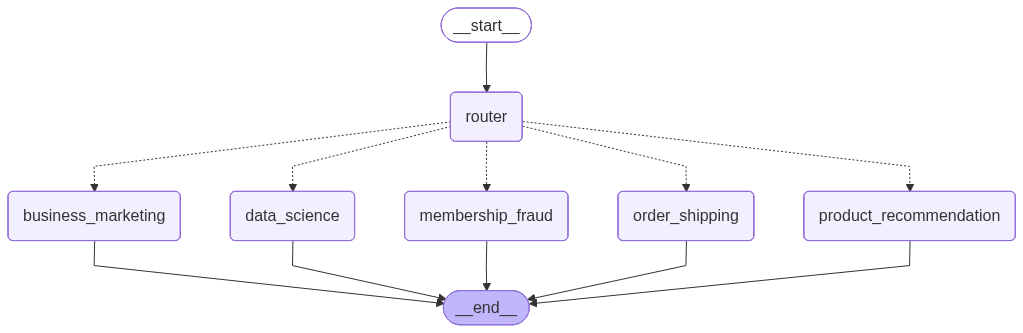

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

## 8. Complete Run — 15 User Stories (3 per Agent)

This is the **complete implementation run** required by Phase 3 Requirement 3.

| Agent | US1 | US2 | US3 |
|-------|-----|-----|-----|
| Business / Marketing | Black Friday Campaign ROI | Q2 Content Strategy | Competitor Analysis |
| Data Science | Cycling Performance | Workout Consistency | Demographic Report |
| Membership / Fraud | Suspicious Devices | Password Reset | Tier Comparison |
| Order / Shipping | Order Tracking | Return Process | Delayed Escalation |
| Product Recommendation | Yoga Accessories | Bike vs Bike+ | Tread Cross-Sell |

In [14]:
def run_demo(query: str) -> dict:
    initial: AgentState = {
        "user_input": query, "routed_to": "", "agent_response": "",
        "human_review": False, "trace": [],
    }
    return app.invoke(initial)

def print_result(label, query):
    print("=" * 80)
    print(f"[{label}]")
    print(f"User: {query}\n")
    result = run_demo(query)
    print(f"Routed to:    {result['routed_to']}")
    print(f"Review flag:  {result['human_review']}")
    print(f"Trace:        {' | '.join(result['trace'])}")
    print(f"\nAgent response:\n{result['agent_response']}\n")

### 8.1 Business / Marketing Agent — US1, US2, US3


In [15]:
# ── Business / Marketing: 3 User Stories ─────────────────────────────────────

print_result("BM-US1: Black Friday Campaign ROI",
    "Analyze the Black Friday Tread Campaign. Which ads performed best and how should I reallocate budget for the next cycle?")

print_result("BM-US2: Q2 Content Strategy",
    "What content themes get the most engagement among our members? Suggest 3 topics for our Q2 social media calendar.")

print_result("BM-US3: Competitor Analysis",
    "How is Peloton membership growth comparing to NordicTrack and Echelon? What content strategies are they using?")

[BM-US1: Black Friday Campaign ROI]
User: Analyze the Black Friday Tread Campaign. Which ads performed best and how should I reallocate budget for the next cycle?

Routed to:    business_marketing
Review flag:  False
Trace:        Router -> business_marketing (review=False) | BusinessMarketingAgent executed

Agent response:
The Black Friday Tread Campaign's top-performing ads by click-through rate (CTR) were:

1. **'Fall Into Fitness' video ad** – 4.8% CTR
2. **'Ride With Us' carousel** – 3.9% CTR
3. **'Your Goals, Our Classes' static** – 3.2% CTR

The campaign achieved a 2,330% ROI with a total spend of $210,000, generating $5,103,000 in revenue. The video ad format, particularly 'Fall Into Fitness', significantly outperformed other formats.

For the next campaign cycle, I recommend reallocating 15–20% of the budget from static ads, like 'Static Banner v2' which had a low 1.1% CTR, towards video and carousel formats. This should enhance engagement and conversion rates based on current

### 8.2 Data Science Agent — US1, US2, US3


In [16]:
# ── Data Science: 3 User Stories ─────────────────────────────────────────────

print_result("DS-US1: Cycling Performance",
    "Member ID M-4421: review my last 30 cycling classes and tell me how to improve my average output and cadence.")

print_result("DS-US2: Workout Consistency",
    "Member ID M-4421: I feel like I have been inconsistent lately. Show me my workout patterns over the last 3 months and recommend a schedule.")

print_result("DS-US3: Demographic Class Report",
    "What are the most popular class types for members aged 25-34 in the Northeast? Which instructors have the highest completion rates?")

[DS-US1: Cycling Performance]
User: Member ID M-4421: review my last 30 cycling classes and tell me how to improve my average output and cadence.

Routed to:    data_science
Review flag:  False
Trace:        Router -> data_science (review=False) | DataScienceAgent executed

Agent response:
I reviewed your last 30 cycling classes, and here's what I found:

**Average Output:** Your average output is 312 kJ, which is a 4.2% improvement compared to your previous 30 classes. You're performing above the average for your peers, who have an average output of 298 kJ. However, to reach the top quartile (365 kJ), there's room for growth.

**Average Cadence:** Your average cadence is 86 RPM, which is slightly down by 1.1% from your previous 30 classes. This is still a solid cadence, but maintaining or slightly increasing it could enhance your performance.

**Recommendations for Improvement:**
1. **Increase Resistance Intervals:** Since your resistance is at 42 on average, try incorporating more hi

### 8.3 Membership / Fraud Agent — US1, US2, US3


In [17]:
# ── Membership / Fraud: 3 User Stories ───────────────────────────────────────

print_result("MF-US1: Suspicious Device Activity",
    "Member ID M-4421: show me every device that logged into my account in the last 30 days and help me revoke any I do not recognize.")

print_result("MF-US2: Password Reset",
    "I am locked out of my Peloton account after entering the wrong password too many times. My member ID is M-4421. Help me reset it.")

print_result("MF-US3: Membership Tier Comparison",
    "I only use the Peloton app on my phone, no equipment. What is the difference between All-Access and App+? Which one should I get?")

[MF-US1: Suspicious Device Activity]
User: Member ID M-4421: show me every device that logged into my account in the last 30 days and help me revoke any I do not recognize.

Routed to:    membership_fraud
Review flag:  False
Trace:        Router -> membership_fraud (review=False) | MembershipFraudAgent executed

Agent response:
Here are the devices that accessed your account in the last 30 days:

| Device | Location | Last Login | Status |
|---|---|---|---|
| Peloton Bike+ | Worcester, MA | 2 hours ago | ✅ Recognized |
| iPhone 15 | Worcester, MA | 1 day ago | ✅ Recognized |
| Android (Chrome) | Seattle, WA | 4 hours ago | ⚠️ Unrecognized |

The Android device in Seattle is flagged as unrecognized. I recommend revoking its access. Shall I proceed with revoking access for this device?

[MF-US2: Password Reset]
User: I am locked out of my Peloton account after entering the wrong password too many times. My member ID is M-4421. Help me reset it.

Routed to:    membership_fraud
Review flag

### 8.4 Order / Shipping Agent — US1, US2, US3


In [18]:
# ── Order / Shipping: 3 User Stories ─────────────────────────────────────────

print_result("OS-US1: Order Tracking",
    "Where is my Peloton Bike+ order PL-2024-98432 right now, and when will it be delivered?")

print_result("OS-US2: Return Process",
    "I want to return my Peloton cycling shoes from order PL-2024-77210. They arrived with a broken buckle.")

print_result("OS-US3: Delayed Order Escalation",
    "My Peloton Guide order PL-2024-55001 has not shipped after 7 days. The expected ship date was 5 days ago. Member ID M-4421. Please escalate this.")

[OS-US1: Order Tracking]
User: Where is my Peloton Bike+ order PL-2024-98432 right now, and when will it be delivered?

Routed to:    order_shipping
Review flag:  False
Trace:        Router -> order_shipping (review=False) | OrderShippingAgent executed

Agent response:
I've pulled up your order #PL-2024-98432 for the Peloton Bike+. Here's the current status:

- **Status:** In Transit
- **Current Location:** XPO Logistics hub - Springfield, MA
- **Estimated Delivery:** April 10, 2026
- **Delivery Window:** 9:00 AM – 1:00 PM
- **Carrier:** XPO
- **Tracking Number:** XPO9982341

Please note that a signature will be required upon delivery. You'll receive a notification approximately 30 minutes before the delivery team arrives. Is there anything else you need for the delivery?

[OS-US2: Return Process]
User: I want to return my Peloton cycling shoes from order PL-2024-77210. They arrived with a broken buckle.

Routed to:    order_shipping
Review flag:  False
Trace:        Router -> order_sh

### 8.5 Product Recommendation Agent — US1, US2, US3


In [19]:
# ── Product Recommendation: 3 User Stories ───────────────────────────────────

print_result("PR-US1: Yoga Accessories",
    "Member ID M-4421: I have been doing a lot of yoga classes lately. Recommend a Peloton yoga mat and blocks I should buy.")

print_result("PR-US2: Bike vs Bike+ Comparison",
    "I have a $1,500 budget. What is the difference between the Peloton Bike and the Bike+? Which one should I get?")

print_result("PR-US3: Cross-Sell Tread Bundles",
    "A customer just bought a Peloton Tread and mentions they also want to do strength training. What bundles should I recommend?")

[PR-US1: Yoga Accessories]
User: Member ID M-4421: I have been doing a lot of yoga classes lately. Recommend a Peloton yoga mat and blocks I should buy.

Routed to:    product_recommendation
Review flag:  False
Trace:        Router -> product_recommendation (review=False) | ProductRecommendationAgent executed

Agent response:
It seems there are currently no specific yoga mats or blocks available in the Peloton product catalog. However, based on your yoga class history (28 classes in the last 90 days, averaging about 3.1 classes per week), I can still provide some general recommendations for when these products are back in stock:

1. **Peloton Reversible Yoga Mat**: This mat typically features 6mm dual-layer cushioning and a non-slip surface on both sides, which is ideal for your Power Yoga and Slow Flow classes. It's designed to provide comfort and stability during your sessions.

2. **Peloton Yoga Block Set (2 pack)**: High-density EVA foam blocks are great for alignment support, espe

## 9. Regression Test — Router Classification

In [20]:
def load_testing_queries(agent_slug: str, limit: int = 3) -> list:
    path = os.path.join(TRAINING_DIR, f"{agent_slug}_testing.json")
    if not os.path.exists(path):
        return []
    with open(path) as f:
        data = json.load(f)
    items = data.get("testing_data", data.get("training_data", []))[:limit]
    out = []
    for item in items:
        if "input" in item:
            out.append(item["input"])
        elif "messages" in item:
            user = next((m["content"] for m in item["messages"] if m["role"] == "user"), "")
            if user:
                out.append(user)
    return out

def test_router_only(query: str) -> str:
    return router_node({
        "user_input": query, "routed_to": "", "agent_response": "",
        "human_review": False, "trace": []
    })["routed_to"]

for slug in ["business_marketing", "data_science", "membership_fraud", "order_shipping", "product_recommendation"]:
    for q in load_testing_queries(slug, limit=3):
        predicted = test_router_only(q)
        ok = "PASS" if predicted == slug else "FAIL"
        print(f"[{ok}] expected={slug:22s} got={predicted:22s} | {q[:70]}")

[PASS] expected=business_marketing     got=business_marketing     | How did our email campaign ROI compare to paid social in Q4?
[PASS] expected=business_marketing     got=business_marketing     | Which ad format performed best across all Q3 campaigns?
[PASS] expected=business_marketing     got=business_marketing     | What content worked best for member re-engagement last year?
[PASS] expected=data_science           got=data_science           | Show me my fitness progress over the last 3 months.
[PASS] expected=data_science           got=data_science           | I want to improve my cadence. What should I focus on?
[PASS] expected=data_science           got=data_science           | Why did I stop working out consistently in October?
[PASS] expected=membership_fraud       got=membership_fraud       | I think someone else is using my Peloton account.
[PASS] expected=membership_fraud       got=membership_fraud       | Who accessed my Peloton account from an unrecognized device, and how c